In [19]:
import pandas as pd
import numpy as np
from skimpy import clean_columns
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from datetime import datetime
import scipy.stats as stats
import scikit_posthocs as sp

# from datetime import timedelta


## Wire Mesh Data

In [15]:
# Read 2023 wire mesh data.

wm_2023 = pd.read_csv("Data/2023_wire_mesh_clean.csv")
wm_2023["total_scm"] = wm_2023["scm_larvae_sum"] + wm_2023["scm_pupae_sum"]
wm_2023.head()


,field_id,collection_date,seed_type,number_seeds,scm_larvae_sum,scm_pupae_sum,scm_seeds,total_scm
0,POV_DUN,4/18/23,Corn,10.0,0,0,0,0
1,POV_DUN,4/18/23,Bean,11.0,1,0,1,1
2,DIP_CUR,4/18/23,Bean,5.0,0,17,0,17
3,DIP_CUR,4/18/23,Corn,9.0,0,0,0,0
4,DIP_PAT,4/18/23,Corn,10.0,0,0,0,0


In [8]:
# Read 2024 wire mesh data.

wm_2024 = pd.read_csv("Data/2024_wire_mesh_clean.csv")
wm_2024["total_scm"] = wm_2024["scm_larvae_sum"] + wm_2024["scm_pupae_sum"]
wm_2024


,field_id,collection_date,number_seeds,scm_seeds,seed_type,scm_larvae_sum,scm_pupae_sum,total_scm
0,DEG_DIE_HILL,4/15/24,10,0,lima,0,0,0
1,DEG_DIE_HILL,4/15/24,10,0,corn,0,0,0
2,DEG_DIE_HILL,4/15/24,10,0,soy,0,0,0
3,DEG_DIE_HILL,4/29/24,10,0,corn,0,0,0
4,DEG_DIE_HILL,4/15/24,10,0,lima,0,0,0
...,...,...,...,...,...,...,...,...
614,ZUE_REE,5/21/24,10,0,soy,0,0,0
615,ZUE_REE,5/21/24,9,0,soy,0,0,0
616,ZUE_REE,5/21/24,9,0,lima,0,0,0
617,ZUE_REE,5/21/24,10,0,corn,0,0,0


In [11]:
# Combine 2023 and 2024 wire mesh data. Rename seed types for consistency.

wm = pd.concat([wm_2023, wm_2024], axis=0)
wm["seed_type"] = wm["seed_type"].str.lower()
wm["seed_type"] = wm["seed_type"].replace("bean", "lima bean")
wm["seed_type"] = wm["seed_type"].replace("lima", "lima bean")
wm["seed_type"] = wm["seed_type"].replace("soy", "soybean")
wm["seed_type"] = wm["seed_type"].str.capitalize()
wm["prop_seeds"] = wm["scm_seeds"] / wm["number_seeds"]
wm


,field_id,collection_date,seed_type,number_seeds,scm_larvae_sum,scm_pupae_sum,scm_seeds,total_scm,prop_seeds
0,POV_DUN,4/18/23,Corn,10.0,0,0,0,0,0.000000
1,POV_DUN,4/18/23,Lima bean,11.0,1,0,1,1,0.090909
2,DIP_CUR,4/18/23,Lima bean,5.0,0,17,0,17,0.000000
3,DIP_CUR,4/18/23,Corn,9.0,0,0,0,0,0.000000
4,DIP_PAT,4/18/23,Corn,10.0,0,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...
614,ZUE_REE,5/21/24,Soybean,10.0,0,0,0,0,0.000000
615,ZUE_REE,5/21/24,Soybean,9.0,0,0,0,0,0.000000
616,ZUE_REE,5/21/24,Lima bean,9.0,0,0,0,0,0.000000
617,ZUE_REE,5/21/24,Corn,10.0,0,0,0,0,0.000000


#### Figure 4A

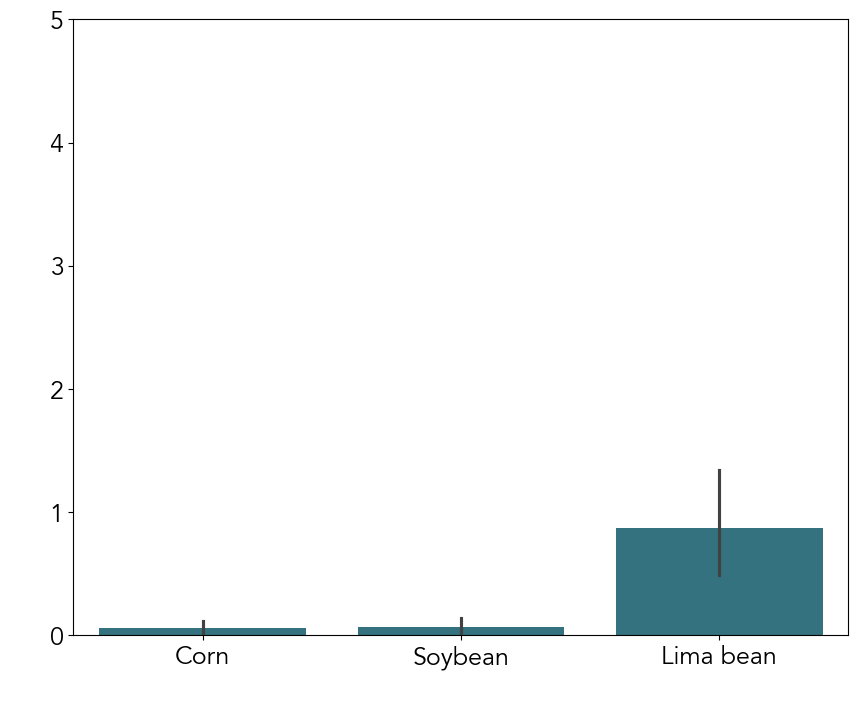

In [12]:
plt.rcParams["font.sans-serif"] = ["Avenir"]
plt.figure(figsize=(10, 8))

plt.rcParams.update({"font.size": 18})

sns.barplot(
    data=wm,
    x="seed_type",
    y="total_scm",
    color="#287a8c",
    order=["Corn", "Soybean", "Lima bean"],
)

plt.xlabel(" ", labelpad=10)
plt.ylabel(" ", labelpad=10)
plt.ylim(0, 5)
plt.show()


In [14]:
# Mean - SCM per seed.

wm.groupby("seed_type").mean("total_scm")["total_scm"]


seed_type
Corn         0.058824
Lima bean    0.873529
Soybean      0.068627
Name: total_scm, dtype: float64

In [16]:
# SEM - SCM per seed.

wm.groupby("seed_type")["total_scm"].sem()


seed_type
Corn         0.027735
Lima bean    0.230984
Soybean      0.034412
Name: total_scm, dtype: float64

In [17]:
# Kruskal-Wallis test for mean number of SCM per seed.

group1 = wm.loc[wm["seed_type"] == "Corn"]["total_scm"]
group2 = wm.loc[wm["seed_type"] == "Soybean"]["total_scm"]
group3 = wm.loc[wm["seed_type"] == "Lima bean"]["total_scm"]
statistic, p_value = stats.kruskal(group1, group2, group3)
print("Kruskal-Wallis H statistic:", statistic)
print("P-value:", p_value)


Kruskal-Wallis H statistic: 63.85777549840065
P-value: 1.3597536623493051e-14


In [20]:
# Dunn's test for mean number of SCM per seed.

data = [group1, group2, group3]
p_values = sp.posthoc_dunn(data, p_adjust="holm")

print(p_values)


              1             2             3
1  1.000000e+00  8.065956e-01  6.058532e-13
2  8.065956e-01  1.000000e+00  3.001428e-09
3  6.058532e-13  3.001428e-09  1.000000e+00


#### Figure 4B

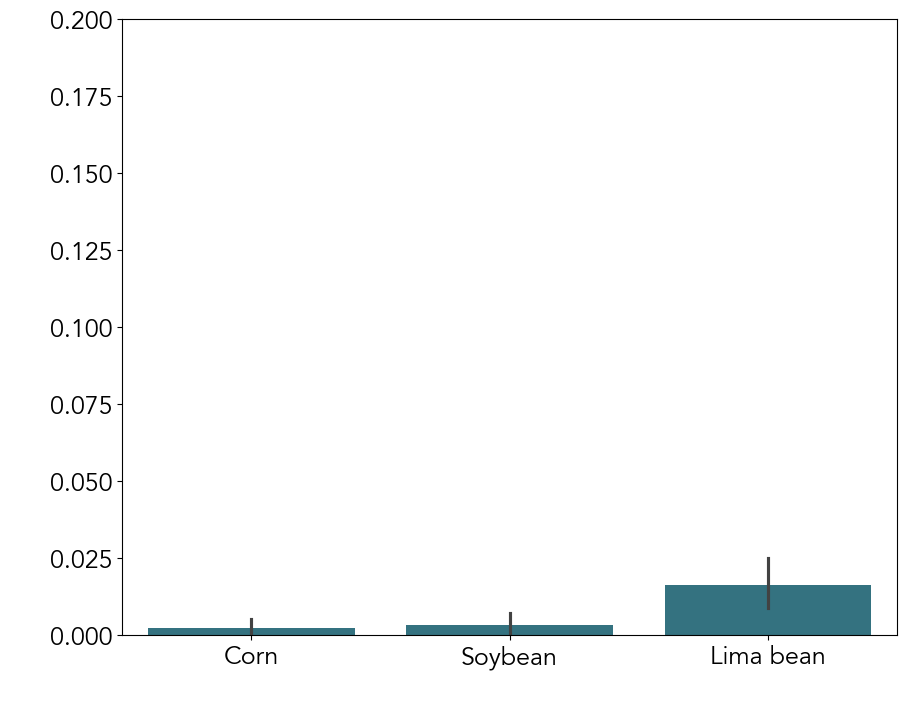

In [22]:
plt.rcParams["font.sans-serif"] = ["Avenir"]
plt.figure(figsize=(10, 8))

plt.rcParams.update({"font.size": 18})

sns.barplot(
    data=wm.reset_index(),
    x="seed_type",
    y="prop_seeds",
    color="#287a8c",
    order=["Corn", "Soybean", "Lima bean"],
)

plt.xlabel(" ", labelpad=10)
plt.ylabel(" ", labelpad=10)
plt.ylim(0, 0.2)
plt.show()


In [24]:
# Mean - proportion seeds damaged.

wm.groupby("seed_type").mean("prop_seeds")["prop_seeds"]


seed_type
Corn         0.002298
Lima bean    0.016363
Soybean      0.003392
Name: prop_seeds, dtype: float64

In [ ]:
# SEM - proportion seeds damaged.

wm.groupby("seed_type")["prop_seeds"].sem()


In [26]:
# Kruskal-Wallis test for proportion seeds damaged.

group1 = wm.loc[wm["seed_type"] == "Corn"]["prop_seeds"].dropna()
group2 = wm.loc[wm["seed_type"] == "Soybean"]["prop_seeds"].dropna()
group3 = wm.loc[wm["seed_type"] == "Lima bean"]["prop_seeds"].dropna()
statistic, p_value = stats.kruskal(group1, group2, group3)
print("Kruskal-Wallis H statistic:", statistic)
print("P-value:", p_value)


Kruskal-Wallis H statistic: 26.27496269958437
P-value: 1.9699914609002246e-06


In [27]:
# Dunn's test for proportion seeds damaged.

data = [group1, group2, group3]
p_values = sp.posthoc_dunn(data, p_adjust="holm")

print(p_values)


          1         2         3
1  1.000000  0.610519  0.000004
2  0.610519  1.000000  0.000561
3  0.000004  0.000561  1.000000


## Sticky Card Data

In [39]:
# Read and clean 2023 sticky card data.

scm_2023 = pd.read_csv("Data/2023_scm_counts.csv")
scm_2023 = clean_columns(scm_2023)
scm_2023["date_collected"] = pd.to_datetime(
    scm_2023["date_collected"], format="%m/%d/%y"
)

scm_2023[
    [
        "n_scm_i_m",
        "n_scm_o_m",
        "n_scm_i_f",
        "n_scm_o_f",
        "n_d_florilega_i",
        "n_d_florilega_o",
    ]
] = scm_2023[
    [
        "n_scm_i_m",
        "n_scm_o_m",
        "n_scm_i_f",
        "n_scm_o_f",
        "n_d_florilega_i",
        "n_d_florilega_o",
    ]
].apply(
    pd.to_numeric, errors="coerce"
)
scm_2023["scm_male"] = scm_2023["n_scm_i_m"] + scm_2023["n_scm_o_m"]
scm_2023["scm_female"] = scm_2023["n_scm_i_f"] + scm_2023["n_scm_o_f"]
scm_2023["total_scm"] = (
    scm_2023["n_scm_i_m"]
    + scm_2023["n_scm_o_m"]
    + scm_2023["n_scm_i_f"]
    + scm_2023["n_scm_o_f"]
)
scm_2023 = scm_2023.dropna(subset=["total_scm"])
scm_2023["florilega"] = scm_2023["n_d_florilega_i"] + scm_2023["n_d_florilega_o"]
scm_2023["total_flies"] = scm_2023["total_scm"] + scm_2023["florilega"]

scm_2023["week"] = scm_2023["date_collected"].dt.isocalendar().week.astype(int)
scm_2023["year"] = scm_2023["date_collected"].dt.isocalendar().year

scm_2023.head()


/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_92710/4288923107.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scm_2023['florilega'] = scm_2023['n_d_florilega_i'] + scm_2023['n_d_florilega_o']
/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_92710/4288923107.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scm_2023['total_flies'] = scm_2023['total_scm'] + scm_2023['florilega']


,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,total_scm,florilega,total_flies,week,year
1,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,304.0,24.0,328.0,25,2023
2,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,81.0,1.0,82.0,24,2023
4,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,18.0,0.0,18.0,22,2023
7,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,100.0,0.0,100.0,21,2023
9,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,28.0,0.0,28.0,20,2023


In [38]:
scm_2024 = pd.read_csv("Data/2024_scm_counts.csv")
scm_2024 = clean_columns(scm_2024)
scm_2024["date_collected"] = pd.to_datetime(scm_2024["date_collected"], format="mixed")

scm_2024["scm_male"] = scm_2024["n_scm_m_1"] + scm_2024["n_scm_m_2"]
scm_2024["scm_female"] = scm_2024["n_scm_f_1"] + scm_2024["n_scm_f_2"]
scm_2024["total_scm"] = (
    scm_2024["n_scm_m_1"]
    + scm_2024["n_scm_m_2"]
    + scm_2024["n_scm_f_1"]
    + scm_2024["n_scm_f_2"]
)
scm_2024["florilega"] = scm_2024["n_d_florilega_1"] + scm_2024["n_d_florilega_2"]
scm_2024["total_flies"] = scm_2024["florilega"] + scm_2024["total_scm"]
scm_2024 = scm_2024.dropna(subset=["total_scm"])

scm_2024["week"] = scm_2024["date_collected"].dt.isocalendar().week.astype(int)
scm_2024["year"] = scm_2024["date_collected"].dt.isocalendar().year

scm_2024.head()


/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_92710/2968198743.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scm_2024['week'] = scm_2024['date_collected'].dt.isocalendar().week.astype(int)
/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_92710/2968198743.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scm_2024['year'] = scm_2024['date_collected'].dt.isocalendar().year


,field_id,date_collected,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2,scm_male,scm_female,total_scm,florilega,total_flies,week,year
0,DEG_DIE_2,2024-05-13,17.0,118.0,18.0,42.0,2.0,2.0,35.0,160.0,195.0,4.0,199.0,20,2024
5,DEG_DIE_2,2024-05-28,5.0,6.0,1.0,3.0,0.0,0.0,6.0,9.0,15.0,0.0,15.0,22,2024
6,DEG_DIE_2,2024-06-03,49.0,60.0,30.0,24.0,45.0,10.0,79.0,84.0,163.0,55.0,218.0,23,2024
8,DEG_DIE_2,2024-06-11,45.0,24.0,78.0,58.0,3.0,20.0,123.0,82.0,205.0,23.0,228.0,24,2024
11,DEG_DIE_2,2024-06-17,33.0,13.0,23.0,17.0,19.0,12.0,56.0,30.0,86.0,31.0,117.0,25,2024


In [37]:
sticky_cards_merged = pd.concat([scm_2023, scm_2024])
sticky_cards_merged.head()


,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,florilega,total_flies,week,year,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2
1,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,24.0,328.0,25,2023,NaN,NaN,NaN,NaN,NaN,NaN
2,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,1.0,82.0,24,2023,NaN,NaN,NaN,NaN,NaN,NaN
4,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,0.0,18.0,22,2023,NaN,NaN,NaN,NaN,NaN,NaN
7,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,0.0,100.0,21,2023,NaN,NaN,NaN,NaN,NaN,NaN
9,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,0.0,28.0,20,2023,NaN,NaN,NaN,NaN,NaN,NaN


#### Fig. 5A

(9.0, 52.0)

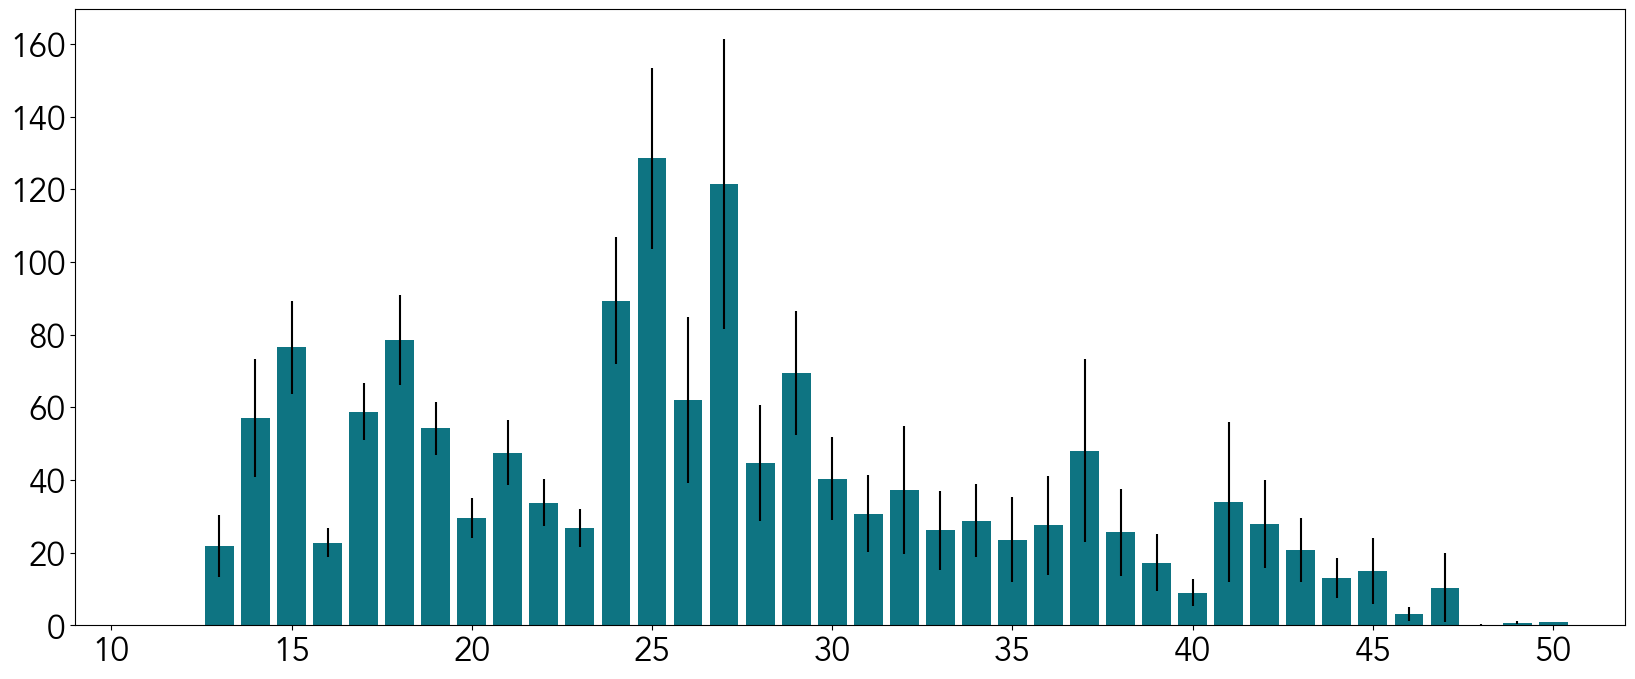

In [40]:
plt.rcParams["font.sans-serif"] = ["Avenir"]
plt.figure(figsize=(20, 8))
plt.rcParams.update({"font.size": 24})

grouped_2023 = (
    sticky_cards_merged.loc[sticky_cards_merged["year"] == 2023]
    .groupby("week")["total_flies"]
    .mean()
    .reset_index()
)
se_2023 = (
    sticky_cards_merged.loc[sticky_cards_merged["year"] == 2023]
    .groupby("week")["total_flies"]
    .sem()
    .reset_index()
)

plt.bar(grouped_2023["week"], grouped_2023["total_flies"], color="#0e7482")
plt.errorbar(
    x=grouped_2023["week"],
    y=grouped_2023["total_flies"],
    yerr=se_2023["total_flies"],
    ecolor="black",
    fmt="None",
)
plt.xlim(9, 52)


#### Fig. 5B

(9.0, 52.0)

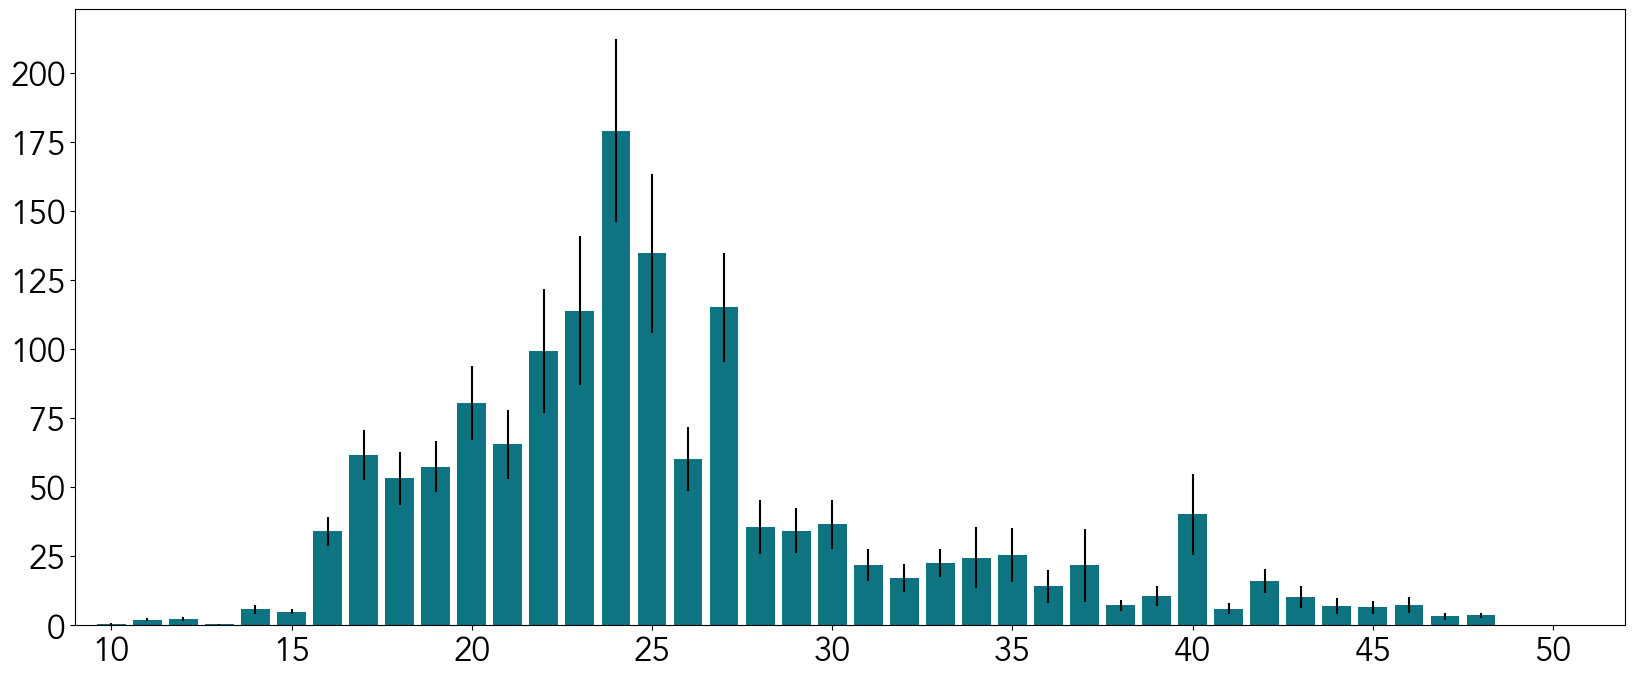

In [41]:
plt.rcParams["font.sans-serif"] = ["Avenir"]
plt.figure(figsize=(20, 8))
plt.rcParams.update({"font.size": 24})


grouped_2024 = (
    sticky_cards_merged.loc[sticky_cards_merged["year"] == 2024]
    .groupby("week")["total_flies"]
    .mean()
    .reset_index()
)
se_2024 = (
    sticky_cards_merged.loc[sticky_cards_merged["year"] == 2024]
    .groupby("week")["total_flies"]
    .sem()
    .reset_index()
)

plt.bar(grouped_2024["week"], grouped_2024["total_flies"], color="#0e7482")
plt.errorbar(
    x=grouped_2024["week"],
    y=grouped_2024["total_flies"],
    yerr=se_2024["total_flies"],
    ecolor="black",
    fmt="None",
)
plt.xlim(9, 52)


## Climate

In [43]:
climate_2023 = pd.read_csv("Data/2023_climate.csv")
climate_2023["date"] = pd.to_datetime(climate_2023["date"], format="%m/%d/%y")
climate_2023["week"] = climate_2023["date"].dt.isocalendar().week
climate_2023 = (
    climate_2023[
        [
            "field_id",
            "week",
            "ppt_in",
            "tmin_f",
            "tmean_f",
            "tmax_f",
            "tdmean_f",
            "vpdmin_hPa",
            "vpdmax_hPa",
        ]
    ]
    .groupby(["field_id", "week"])
    .mean()
)
climate_2023["year"] = 2023
climate_2023 = climate_2023.reset_index()
climate_2023.head()


,field_id,week,ppt_in,tmin_f,tmean_f,tmax_f,tdmean_f,vpdmin_hPa,vpdmax_hPa,year
0,DEG_DIE_HILL,1,0.144286,33.014286,39.142857,45.214286,35.685714,0.241429,2.728571,2023
1,DEG_DIE_HILL,2,0.114286,22.571429,27.885714,33.185714,24.714286,0.288571,1.651429,2023
2,DEG_DIE_HILL,3,0.168571,24.700000,29.342857,33.971429,27.071429,0.171429,1.292857,2023
3,DEG_DIE_HILL,4,0.111429,24.385714,29.571429,34.742857,24.800000,0.218571,2.294286,2023
4,DEG_DIE_HILL,5,0.018571,5.085714,15.485714,25.900000,10.642857,0.175714,2.072857,2023


In [46]:
climate_2024 = pd.read_csv("Data/2024_climate.csv")
climate_2024["date"] = pd.to_datetime(climate_2024["date"], format="%m/%d/%y")
climate_2024["week"] = climate_2024["date"].dt.isocalendar().week
climate_2024 = (
    climate_2024[
        [
            "field_id",
            "week",
            "ppt_in",
            "tmin_f",
            "tmean_f",
            "tmax_f",
            "tdmean_f",
            "vpdmin_hPa",
            "vpdmax_hPa",
        ]
    ]
    .groupby(["field_id", "week"])
    .mean()
)
climate_2024["year"] = 2024
climate_2024 = climate_2024.reset_index()

dict = {
    "DEG_DIE_HILL": "DEG_DIE_2",
    "DEG_FOU_WOOD": "DEG_FOU_2",
    "DEG_PER_STRI": "DEG_PER_2",
    "DEG_VIL": "DEG_VIL_2",
}
climate_2024 = climate_2024.replace({"field_id": dict})
climate_2024.head()


,field_id,week,ppt_in,tmin_f,tmean_f,tmax_f,tdmean_f,vpdmin_hPa,vpdmax_hPa,year
0,DEG_DIE_2,1,0.100000,25.822222,30.622222,35.455556,26.866667,0.253333,1.995556,2024
1,DEG_DIE_2,2,0.215714,28.842857,33.657143,38.471429,28.828571,0.174286,2.194286,2024
2,DEG_DIE_2,3,0.045714,8.271429,14.371429,20.471429,7.671429,0.300000,1.532857,2024
3,DEG_DIE_2,4,0.332857,25.000000,31.500000,37.971429,29.028571,0.091429,1.611429,2024
4,DEG_DIE_2,5,0.118571,27.171429,30.285714,33.414286,27.642857,0.270000,1.182857,2024


In [49]:
# Data cleaning for consistent site naming. 

scm_2023 = scm_2023.replace({'SMI_JOH ': 'SMI_JOH'})
scm_2023 = scm_2023[scm_2023.field_id != 'ZUE_FLE']

scm_2024 = scm_2024.replace({'SMI_JOH ': 'SMI_JOH'})
scm_2024 = scm_2024[scm_2024.field_id != 'ZUE_FLE']

dict = {'DEG_PER_STRI': 'DEG_PER_STRIP', 'DEG_YOU_BOCE': 'DEG_YOU_BOCES', 'DEG_YOU_JONE': 'DEG_YOU_JONES', 'DEG_YOU_OSHE': 'DEG_YOU_OSHEA'
        }
climate_2023 = climate_2023.replace({'field_id': dict})
climate_2024 = climate_2024.replace({'field_id': dict})

dict = {'DEG_DIE_HILL': 'DEG_DIE_2', 'DEG_FOU_WOOD': 'DEG_FOU_2', 'DEG_PER_STRIP': 'DEG_PER_2', 'DEG_VIL': 'DEG_VIL_2', 
        'KAT_TEE_2': 'KAT_TEE_3', 'SMI_COB': 'SMI_COB_3'
        }
scm_2024 = scm_2024.replace({'field_id': dict})

In [50]:
# Merge sticky card data and climate data 2023. 

scm_2023 = scm_2023.merge(climate_2023, on=['field_id', 'week', 'year'])
scm_2023.head()

,field_id,date_collected,n_scm_i_m,n_scm_i_f,n_scm_o_m,n_scm_o_f,n_d_florilega_i,n_d_florilega_o,scm_male,scm_female,...,total_flies,week,year,ppt_in,tmin_f,tmean_f,tmax_f,tdmean_f,vpdmin_hPa,vpdmax_hPa
0,DEG_DIE_HILL,2023-06-23,109.0,84.0,60.0,51.0,14.0,10.0,169.0,135.0,...,328.0,25,2023,0.171429,56.971429,66.414286,75.857143,57.942857,0.822857,13.818571
1,DEG_DIE_HILL,2023-06-13,50.0,23.0,6.0,2.0,1.0,0.0,56.0,25.0,...,82.0,24,2023,0.340000,54.128571,61.800000,69.514286,52.514286,1.064286,12.205714
2,DEG_DIE_HILL,2023-06-01,7.0,2.0,4.0,5.0,0.0,0.0,11.0,7.0,...,18.0,22,2023,0.000000,49.985714,66.228571,82.428571,47.800000,1.715714,27.422857
3,DEG_DIE_HILL,2023-05-26,41.0,31.0,20.0,8.0,0.0,0.0,61.0,39.0,...,100.0,21,2023,0.002857,40.285714,54.400000,68.485714,41.442857,0.651429,15.135714
4,DEG_DIE_HILL,2023-05-18,21.0,0.0,4.0,3.0,0.0,0.0,25.0,3.0,...,28.0,20,2023,0.018571,37.685714,50.642857,63.628571,35.571429,1.245714,13.838571


In [51]:
# Merge sticky card data and climate data 2024. 

scm_2024 = scm_2024.merge(climate_2024, on=['field_id', 'week', 'year'])
scm_2024.head()

,field_id,date_collected,n_scm_m_1,n_scm_f_1,n_scm_m_2,n_scm_f_2,n_d_florilega_1,n_d_florilega_2,scm_male,scm_female,...,total_flies,week,year,ppt_in,tmin_f,tmean_f,tmax_f,tdmean_f,vpdmin_hPa,vpdmax_hPa
0,DEG_DIE_2,2024-05-13,17.0,118.0,18.0,42.0,2.0,2.0,35.0,160.0,...,199.0,20,2024,0.070000,51.385714,58.714286,66.071429,52.728571,0.244286,8.314286
1,DEG_DIE_2,2024-05-28,5.0,6.0,1.0,3.0,0.0,0.0,6.0,9.0,...,15.0,22,2024,0.061429,48.214286,58.757143,69.271429,48.071429,0.731429,13.367143
2,DEG_DIE_2,2024-06-03,49.0,60.0,30.0,24.0,45.0,10.0,79.0,84.0,...,218.0,23,2024,0.378571,55.442857,65.000000,74.571429,56.842857,0.458571,13.478571
3,DEG_DIE_2,2024-06-11,45.0,24.0,78.0,58.0,3.0,20.0,123.0,82.0,...,228.0,24,2024,0.061429,50.371429,59.671429,68.942857,51.100000,0.625714,12.370000
4,DEG_DIE_2,2024-06-17,33.0,13.0,23.0,17.0,19.0,12.0,56.0,30.0,...,117.0,25,2024,0.062857,64.928571,75.285714,85.628571,65.585714,1.124286,19.827143


## Landscape

In [53]:
# Read all landscape data for 2023 and 2024, at both 500m and 1000m radii.

sites_2023_cdl_2022_500m = pd.read_csv('Landscape/Cleaned Landscape/2023_sites_2022_cdl_500m.csv')
sites_2023_cdl_2022_1000m = pd.read_csv('Landscape/Cleaned Landscape/2023_sites_2022_cdl_1000m.csv')

sites_2023_cdl_2023_500m = pd.read_csv('Landscape/Cleaned Landscape/2023_sites_2023_cdl_500m.csv')
sites_2023_cdl_2023_1000m = pd.read_csv('Landscape/Cleaned Landscape/2023_sites_2023_cdl_1000m.csv')

sites_2024_cdl_2023_500m = pd.read_csv('Landscape/Cleaned Landscape/2024_sites_2023_cdl_500m.csv')
sites_2024_cdl_2023_1000m = pd.read_csv('Landscape/Cleaned Landscape/2024_sites_2023_cdl_1000m.csv')

sites_2024_cdl_2024_500m = pd.read_csv('Landscape/Cleaned Landscape/2024_sites_2024_cdl_500m.csv')
sites_2024_cdl_2024_1000m = pd.read_csv('Landscape/Cleaned Landscape/2024_sites_2024_cdl_1000m.csv')

In [54]:
# Calculate proportion of landscape types - 2023 sticky card data, 2022 CDL, 500m radius. 

sites_2023_cdl_2022_500m = sites_2023_cdl_2022_500m[['Name', 'Corn', 'Sweet Corn', 'Soybeans', 'Ag', 'Nat', 'Total', 'Grassland/Pasture']]
sites_2023_cdl_2022_500m['Prop Corn'] = (sites_2023_cdl_2022_500m['Corn'] + sites_2023_cdl_2022_500m['Sweet Corn']) / sites_2023_cdl_2022_500m['Total']
sites_2023_cdl_2022_500m['Prop Soy'] = sites_2023_cdl_2022_500m['Soybeans'] / sites_2023_cdl_2022_500m['Total']
sites_2023_cdl_2022_500m['Prop Ag'] = sites_2023_cdl_2022_500m['Ag'] / sites_2023_cdl_2022_500m['Total']
sites_2023_cdl_2022_500m['Prop Nat'] = sites_2023_cdl_2022_500m['Nat'] / sites_2023_cdl_2022_500m['Total']
sites_2023_cdl_2022_500m['Prop Semi Nat'] = sites_2023_cdl_2022_500m['Grassland/Pasture'] / sites_2023_cdl_2022_500m['Total']
sites_2023_cdl_2022_500m = sites_2023_cdl_2022_500m.add_suffix('_PreviousYear_500m')
sites_2023_cdl_2022_500m = clean_columns(sites_2023_cdl_2022_500m)
sites_2023_cdl_2022_500m = sites_2023_cdl_2022_500m.rename(columns={'name_previous_year_500m': 'field_id'})
sites_2023_cdl_2022_500m.head()

,field_id,corn_previous_year_500m,sweet_corn_previous_year_500m,soybeans_previous_year_500m,ag_previous_year_500m,nat_previous_year_500m,total_previous_year_500m,grassland_pasture_previous_year_500m,prop_corn_previous_year_500m,prop_soy_previous_year_500m,prop_ag_previous_year_500m,prop_nat_previous_year_500m,prop_semi_nat_previous_year_500m
0,POV_DUN,11,0,3,171,753,1588,526,0.006927,0.001889,0.107683,0.474181,0.331234
1,DIP_FLE,706,0,11,931,305,1603,278,0.440424,0.006862,0.580786,0.190268,0.173425
2,DIP_CUR,540,0,50,978,212,1593,255,0.338983,0.031387,0.613936,0.133082,0.160075
3,GAB_STE,252,0,0,408,914,1627,211,0.154886,0.000000,0.250768,0.561770,0.129687
4,SMI_CRO,712,0,344,1347,29,1611,168,0.441962,0.213532,0.836127,0.018001,0.104283


In [55]:
# Calculate proportion of landscape types - 2023 sticky card data, 2022 CDL, 1000m radius. 

sites_2023_cdl_2022_1000m = sites_2023_cdl_2022_1000m[['Name', 'Corn', 'Sweet Corn', 'Soybeans', 'Ag', 'Nat', 'Total', 'Grassland/Pasture']]
sites_2023_cdl_2022_1000m['Prop Corn'] = (sites_2023_cdl_2022_1000m['Corn'] + sites_2023_cdl_2022_1000m['Sweet Corn']) / sites_2023_cdl_2022_1000m['Total']
sites_2023_cdl_2022_1000m['Prop Soy'] = sites_2023_cdl_2022_1000m['Soybeans'] / sites_2023_cdl_2022_1000m['Total']
sites_2023_cdl_2022_1000m['Prop Ag'] = sites_2023_cdl_2022_1000m['Ag'] / sites_2023_cdl_2022_1000m['Total']
sites_2023_cdl_2022_1000m['Prop Nat'] = sites_2023_cdl_2022_1000m['Nat'] / sites_2023_cdl_2022_1000m['Total']
sites_2023_cdl_2022_1000m['Prop Semi Nat'] = sites_2023_cdl_2022_1000m['Grassland/Pasture'] / sites_2023_cdl_2022_1000m['Total']
sites_2023_cdl_2022_1000m = sites_2023_cdl_2022_1000m.add_suffix('_PreviousYear_1000m')
sites_2023_cdl_2022_1000m = clean_columns(sites_2023_cdl_2022_1000m)
sites_2023_cdl_2022_1000m = sites_2023_cdl_2022_1000m.rename(columns={'name_previous_year_1000m': 'field_id'})
sites_2023_cdl_2022_1000m.head()

,field_id,corn_previous_year_1000m,sweet_corn_previous_year_1000m,soybeans_previous_year_1000m,ag_previous_year_1000m,nat_previous_year_1000m,total_previous_year_1000m,grassland_pasture_previous_year_1000m,prop_corn_previous_year_1000m,prop_soy_previous_year_1000m,prop_ag_previous_year_1000m,prop_nat_previous_year_1000m,prop_semi_nat_previous_year_1000m
0,POV_DUN,17,0,3,744,3104,6362,1666,0.002672,0.000472,0.116944,0.487897,0.261867
1,DIP_FLE,1985,30,34,4466,921,6399,746,0.314893,0.005313,0.697922,0.143929,0.116581
2,DIP_CUR,2231,0,402,3908,1079,6369,881,0.350290,0.063118,0.613597,0.169414,0.138326
3,GAB_STE,665,0,1,1429,4110,6499,763,0.102323,0.000154,0.219880,0.632405,0.117403
4,SMI_CRO,1395,0,948,4520,651,6454,987,0.216145,0.146886,0.700341,0.100868,0.152928


In [56]:
# Calculate proportion of landscape types - 2023 sticky card data, 2023 CDL, 500m radius. 

sites_2023_cdl_2023_500m = sites_2023_cdl_2023_500m[['Name', 'Corn', 'Sweet Corn', 'Soybeans', 'Ag', 'Nat', 'Total', 'Grassland/Pasture']]
sites_2023_cdl_2023_500m['Prop Corn'] = (sites_2023_cdl_2023_500m['Corn'] + sites_2023_cdl_2023_500m['Sweet Corn']) / sites_2023_cdl_2023_500m['Total']
sites_2023_cdl_2023_500m['Prop Soy'] = sites_2023_cdl_2023_500m['Soybeans'] / sites_2023_cdl_2023_500m['Total']
sites_2023_cdl_2023_500m['Prop Ag'] = sites_2023_cdl_2023_500m['Ag'] / sites_2023_cdl_2023_500m['Total']
sites_2023_cdl_2023_500m['Prop Nat'] = sites_2023_cdl_2023_500m['Nat'] / sites_2023_cdl_2023_500m['Total']
sites_2023_cdl_2023_500m['Prop Semi Nat'] = sites_2023_cdl_2023_500m['Grassland/Pasture'] / sites_2023_cdl_2023_500m['Total']
sites_2023_cdl_2023_500m = sites_2023_cdl_2023_500m.add_suffix('_CurrentYear_500m')
sites_2023_cdl_2023_500m = clean_columns(sites_2023_cdl_2023_500m)
sites_2023_cdl_2023_500m = sites_2023_cdl_2023_500m.rename(columns={'name_current_year_500m': 'field_id'})
sites_2023_cdl_2023_500m.head()

,field_id,corn_current_year_500m,sweet_corn_current_year_500m,soybeans_current_year_500m,ag_current_year_500m,nat_current_year_500m,total_current_year_500m,grassland_pasture_current_year_500m,prop_corn_current_year_500m,prop_soy_current_year_500m,prop_ag_current_year_500m,prop_nat_current_year_500m,prop_semi_nat_current_year_500m
0,POV_DUN,9,0,4,102,1539,3209,876,0.002805,0.001246,0.031786,0.479589,0.272982
1,DIP_FLE,969,5,18,1947,469,3220,392,0.302484,0.005590,0.604658,0.145652,0.121739
2,DIP_CUR,991,0,223,1764,527,3211,462,0.308627,0.069449,0.549362,0.164123,0.143880
3,GAB_STE,289,1,0,607,2063,3243,393,0.089423,0.000000,0.187172,0.636139,0.121184
4,SMI_CRO,577,0,560,1458,327,3232,554,0.178527,0.173267,0.451114,0.101176,0.171411


In [57]:
# Calculate proportion of landscape types - 2023 sticky card data, 2023 CDL, 1000m radius. 

sites_2023_cdl_2023_1000m = sites_2023_cdl_2023_1000m[['Name', 'Corn', 'Sweet Corn', 'Soybeans', 'Ag', 'Nat', 'Total', 'Grassland/Pasture']]
sites_2023_cdl_2023_1000m['Prop Corn'] = (sites_2023_cdl_2023_1000m['Corn'] + sites_2023_cdl_2023_1000m['Sweet Corn']) / sites_2023_cdl_2023_1000m['Total']
sites_2023_cdl_2023_1000m['Prop Soy'] = sites_2023_cdl_2023_1000m['Soybeans'] / sites_2023_cdl_2023_1000m['Total']
sites_2023_cdl_2023_1000m['Prop Ag'] = sites_2023_cdl_2023_1000m['Ag'] / sites_2023_cdl_2023_1000m['Total']
sites_2023_cdl_2023_1000m['Prop Nat'] = sites_2023_cdl_2023_1000m['Nat'] / sites_2023_cdl_2023_1000m['Total']
sites_2023_cdl_2023_1000m['Prop Semi Nat'] = sites_2023_cdl_2023_1000m['Grassland/Pasture'] / sites_2023_cdl_2023_1000m['Total']
sites_2023_cdl_2023_1000m = sites_2023_cdl_2023_1000m.add_suffix('_CurrentYear_1000m')
sites_2023_cdl_2023_1000m = clean_columns(sites_2023_cdl_2023_1000m)
sites_2023_cdl_2023_1000m = sites_2023_cdl_2023_1000m.rename(columns={'name_current_year_1000m': 'field_id'})
sites_2023_cdl_2023_1000m.head()

,field_id,corn_current_year_1000m,sweet_corn_current_year_1000m,soybeans_current_year_1000m,ag_current_year_1000m,nat_current_year_1000m,total_current_year_1000m,grassland_pasture_current_year_1000m,prop_corn_current_year_1000m,prop_soy_current_year_1000m,prop_ag_current_year_1000m,prop_nat_current_year_1000m,prop_semi_nat_current_year_1000m
0,POV_DUN,9,0,4,102,1539,3209,876,0.002805,0.001246,0.031786,0.479589,0.272982
1,DIP_FLE,969,5,18,1947,469,3220,392,0.302484,0.005590,0.604658,0.145652,0.121739
2,DIP_CUR,991,0,223,1764,527,3211,462,0.308627,0.069449,0.549362,0.164123,0.143880
3,GAB_STE,289,1,0,607,2063,3243,393,0.089423,0.000000,0.187172,0.636139,0.121184
4,SMI_CRO,577,0,560,1458,327,3232,554,0.178527,0.173267,0.451114,0.101176,0.171411


In [ ]:
# Calculate proportion of landscape types - 2024 sticky card data, 2023 CDL, 500m radius. 

sites_2024_cdl_2023_500m = sites_2024_cdl_2023_500m[['Field ID', 'Corn', 'Sweet Corn', 'Soybeans', 'Ag', 'Nat', 'Total', 'Grassland/Pasture']]
sites_2024_cdl_2023_500m['Prop Corn'] = (sites_2024_cdl_2023_500m['Corn'] + sites_2024_cdl_2023_500m['Sweet Corn']) / sites_2024_cdl_2023_500m['Total']
sites_2024_cdl_2023_500m['Prop Soy'] = sites_2024_cdl_2023_500m['Soybeans'] / sites_2024_cdl_2023_500m['Total']
sites_2024_cdl_2023_500m['Prop Ag'] = sites_2024_cdl_2023_500m['Ag'] / sites_2024_cdl_2023_500m['Total']
sites_2024_cdl_2023_500m['Prop Nat'] = sites_2024_cdl_2023_500m['Nat'] / sites_2024_cdl_2023_500m['Total']
sites_2024_cdl_2023_500m['Prop Semi Nat'] = sites_2024_cdl_2023_500m['Grassland/Pasture'] / sites_2024_cdl_2023_500m['Total']
sites_2024_cdl_2023_500m = sites_2024_cdl_2023_500m.add_suffix('_PreviousYear_500m')
sites_2024_cdl_2023_500m = clean_columns(sites_2024_cdl_2023_500m)
sites_2024_cdl_2023_500m = sites_2024_cdl_2023_500m.rename(columns={'field_id_previous_year_500m': 'field_id'})
sites_2024_cdl_2023_500m.head()

In [ ]:
# Calculate proportion of landscape types - 2024 sticky card data, 2023 CDL, 1000m radius. 

sites_2024_cdl_2023_1000m = sites_2024_cdl_2023_1000m[['Field ID', 'Corn', 'Sweet Corn', 'Soybeans', 'Ag', 'Nat', 'Total', 'Grassland/Pasture']]
sites_2024_cdl_2023_1000m['Prop Corn'] = (sites_2024_cdl_2023_1000m['Corn'] + sites_2024_cdl_2023_1000m['Sweet Corn']) / sites_2024_cdl_2023_1000m['Total']
sites_2024_cdl_2023_1000m['Prop Soy'] = sites_2024_cdl_2023_1000m['Soybeans'] / sites_2024_cdl_2023_1000m['Total']
sites_2024_cdl_2023_1000m['Prop Ag'] = sites_2024_cdl_2023_1000m['Ag'] / sites_2024_cdl_2023_1000m['Total']
sites_2024_cdl_2023_1000m['Prop Nat'] = sites_2024_cdl_2023_1000m['Nat'] / sites_2024_cdl_2023_1000m['Total']
sites_2024_cdl_2023_1000m['Prop Semi Nat'] = sites_2024_cdl_2023_1000m['Grassland/Pasture'] / sites_2024_cdl_2023_1000m['Total']
sites_2024_cdl_2023_1000m = sites_2024_cdl_2023_1000m.add_suffix('_PreviousYear_1000m')
sites_2024_cdl_2023_1000m = clean_columns(sites_2024_cdl_2023_1000m)
sites_2024_cdl_2023_1000m = sites_2024_cdl_2023_1000m.rename(columns={'field_id_previous_year_1000m': 'field_id'})
sites_2024_cdl_2023_1000m.head()